# PAPER 전략 수정 후보 실험 분석 — 2026-07-22

## TL;DR

- 현재 규칙을 근사한 실험은 전체 757거래일에서 **+22.31%, MDD -23.19%**였지만, 최근 PASS/PUBLISHED 107거래일에서는 **-1.75%, MDD -19.06%**였다.
- 동일 비중과 20% 리밸런싱 밴드는 현재 규칙 대비 의미 있는 개선이 없었다. 8~10% 종목 상한은 MDD를 낮췄지만 평균 투자 비중도 크게 낮아져 수익률이 함께 줄었다.
- 현재 근사 규칙은 123회의 가격 손절 중 92회가 5일 안에 재진입했고 재진입 간격 중앙값은 1일이었다. 넓은 밴드가 회전율을 거의 줄이지 못한 이유는 비중 조정보다 손절·재진입 반복이 지배했기 때문이다.
- 손절을 없앤 진단 실험은 수익과 비용이 개선됐지만 MDD와 최악의 날 손실이 악화됐다. 단순 5일 쿨다운과 더 강한 손절도 성과를 개선하지 못했다. 따라서 손절을 제거하거나 단순 강화할 근거는 없다.
- 전체 이력의 82.1%가 WARNING 선택 실행이고 가격 데이터는 2026-07-09에서 끝난다. 현 단계에서 PAPER 설정 변경을 승인할 만큼 데이터 신뢰도와 통계적 강건성이 충분하지 않다.

## Context & Methods

의사결정 질문은 “현재 PAPER의 손실을 줄이면서 비용 차감 수익률을 개선할 수정안이 있는가?”이다. 모든 후보는 동일한 월별 FA 선택, 일별 KOSPI/TA 조건, 매수 0.115%·매도 0.295% 비용 가정으로 비교했다.

기존 연구 수치를 그대로 재현하는 A0, 현재 운영 규칙 근사 A, 동일 비중 B, 종목 상한 10%/8% C, 리밸런싱 밴드 20% D, 변동성 조절·강화 손절 E를 실행했다. 원인 분리를 위해 15% 상한만 적용한 진단 후보와 손절 후 5거래일 재진입 금지 후보도 함께 실행했다.

### Key Assumptions

- 일별 종가와 비례 비중으로 체결을 근사한다. 장중 손절, 정수 주식, 부분체결, 주문 거절과 모호한 API 결과는 완전하게 재현하지 못한다.
- 전체 구간은 WARNING 실행을 포함하며 연구용 비교다. PASS/PUBLISHED 구간은 107거래일뿐이라 독립 검증 구간으로 보기 어렵다.
- 수익률 개선과 위험 감소를 분리해서 본다. 투자 비중 축소로 생긴 낮은 변동성은 신호 품질 향상으로 해석하지 않는다.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'reports' / 'analysis').exists():
    ROOT = Path.cwd().parents[1]

EXP_ROOT = ROOT / 'reports' / 'analysis' / 'paper_strategy_experiments'
full = json.loads((EXP_ROOT / 'full' / 'metrics.json').read_text(encoding='utf-8'))
recent = json.loads((EXP_ROOT / 'pass_only' / 'metrics.json').read_text(encoding='utf-8'))
returns = pd.read_csv(EXP_ROOT / 'full' / 'daily_returns.csv', index_col=0, parse_dates=True)
events = pd.read_csv(EXP_ROOT / 'full' / 'events.csv')
events['date'] = pd.to_datetime(events['date'])
periods = pd.read_csv(EXP_ROOT / 'full' / 'period_summary.csv')
comparison = pd.read_csv(EXP_ROOT / 'full' / 'comparison_vs_current.csv')

labels = {row['code']: row['label'] for row in full['metadata']['variant_definitions']}
selected = ['A0_LEGACY', 'X_CAP15_ONLY', 'A_CURRENT', 'B_EQUAL', 'C_CAP10', 'C_CAP08', 'D_BAND20', 'E_VOL_RISK']
print('Full window:', full['metadata']['period_start'], 'to', full['metadata']['period_end'])
print('Recent PASS/PUBLISHED window:', recent['metadata']['period_start'], 'to', recent['metadata']['period_end'])
print('Data grades:', full['data_quality']['quality_grade'], '/', recent['data_quality']['quality_grade'])

Full window: 2023-05-31 to 2026-07-09
Recent PASS/PUBLISHED window: 2026-01-30 to 2026-07-09
Data grades: LOW / MEDIUM


## Data Quality

In [2]:
quality = pd.DataFrame([
    {
        'scope': '전체 이력',
        'days': full['summary']['A_CURRENT']['trading_days'],
        'end': full['data_quality']['experiment_end'],
        'selection_runs': full['data_quality']['selection_runs'],
        'warning_share': full['data_quality']['warning_run_share'],
        'price_missing_rate': full['data_quality']['price_missing_rate_after_fill'],
        'grade': full['data_quality']['quality_grade'],
    },
    {
        'scope': 'PASS/PUBLISHED',
        'days': recent['summary']['A_CURRENT']['trading_days'],
        'end': recent['data_quality']['experiment_end'],
        'selection_runs': recent['data_quality']['selection_runs'],
        'warning_share': recent['data_quality']['warning_run_share'],
        'price_missing_rate': recent['data_quality']['price_missing_rate_after_fill'],
        'grade': recent['data_quality']['quality_grade'],
    },
])
quality

,scope,days,end,selection_runs,warning_share,price_missing_rate,grade
0,전체 이력,757,2026-07-09,39,0.820513,0.015850,LOW
1,PASS/PUBLISHED,107,2026-07-09,7,0.000000,0.000284,MEDIUM


전체 구간은 길지만 선택 실행 39개 중 32개가 WARNING이며, 최신 가격도 현재 분석일보다 13일 앞선 7월 9일에 끝난다. 최근 구간은 선택 상태가 더 깨끗하지만 107거래일뿐이고 PBO를 계산할 관측치가 부족하다. 따라서 전체 구간은 방향성 연구, 최근 구간은 스트레스 확인 용도로만 사용한다.

## Results

In [3]:
rows = []
for code in selected:
    f = full['summary'][code]
    r = recent['summary'][code]
    rows.append({
        'variant': code,
        'label': labels[code],
        'full_total_return': f['total_return'],
        'full_cagr': f['cagr'],
        'full_mdd': f['max_drawdown'],
        'full_sharpe': f['sharpe_zero_rf'],
        'full_cost': f['total_cost_ratio'],
        'annual_turnover': f['annualized_turnover'],
        'average_exposure': f['average_exposure'],
        'recent_total_return': r['total_return'],
        'recent_mdd': r['max_drawdown'],
        'recent_sharpe': r['sharpe_zero_rf'],
    })
summary = pd.DataFrame(rows).set_index('variant')
summary.style.format({
    'full_total_return': '{:.2%}', 'full_cagr': '{:.2%}', 'full_mdd': '{:.2%}',
    'full_sharpe': '{:.3f}', 'full_cost': '{:.2%}', 'annual_turnover': '{:.1f}x',
    'average_exposure': '{:.1%}', 'recent_total_return': '{:.2%}',
    'recent_mdd': '{:.2%}', 'recent_sharpe': '{:.3f}',
})

,label,full_total_return,full_cagr,full_mdd,full_sharpe,full_cost,annual_turnover,average_exposure,recent_total_return,recent_mdd,recent_sharpe
variant,,,,,,,,,,,
A0_LEGACY,기존 연구 리플레이,65.92%,18.36%,-23.27%,0.793,11.45%,18.7x,55.9%,21.11%,-16.99%,1.216
X_CAP15_ONLY,진단: 15% 상한만,36.97%,11.04%,-24.51%,0.588,7.09%,11.6x,46.8%,3.65%,-17.61%,0.412
A_CURRENT,현재 규칙 근사,22.31%,6.93%,-23.19%,0.431,13.16%,21.4x,44.8%,-1.75%,-19.06%,0.079
B_EQUAL,동일 비중,22.24%,6.91%,-23.30%,0.434,12.88%,21.0x,44.8%,-0.50%,-18.63%,0.156
C_CAP10,종목 상한 10%,16.07%,5.09%,-16.73%,0.409,8.44%,13.7x,33.7%,-1.83%,-14.94%,-0.023
C_CAP08,종목 상한 8%,13.22%,4.22%,-13.66%,0.405,6.60%,10.7x,27.3%,-1.29%,-12.05%,-0.031
D_BAND20,리밸런싱 밴드 20%,22.24%,6.91%,-23.78%,0.429,12.65%,20.6x,44.9%,-0.60%,-18.69%,0.151
E_VOL_RISK,변동성 조절·강화 손절,1.34%,0.44%,-19.25%,0.097,8.31%,13.5x,26.5%,-7.27%,-17.66%,-0.728


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\2348014244.py:12: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\2348014244.py:12: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\2348014244.py:12: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\2348014244.py:12: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\2348014244.py:12: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\2348014244.py:12: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from current font.
  plt

C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) mi

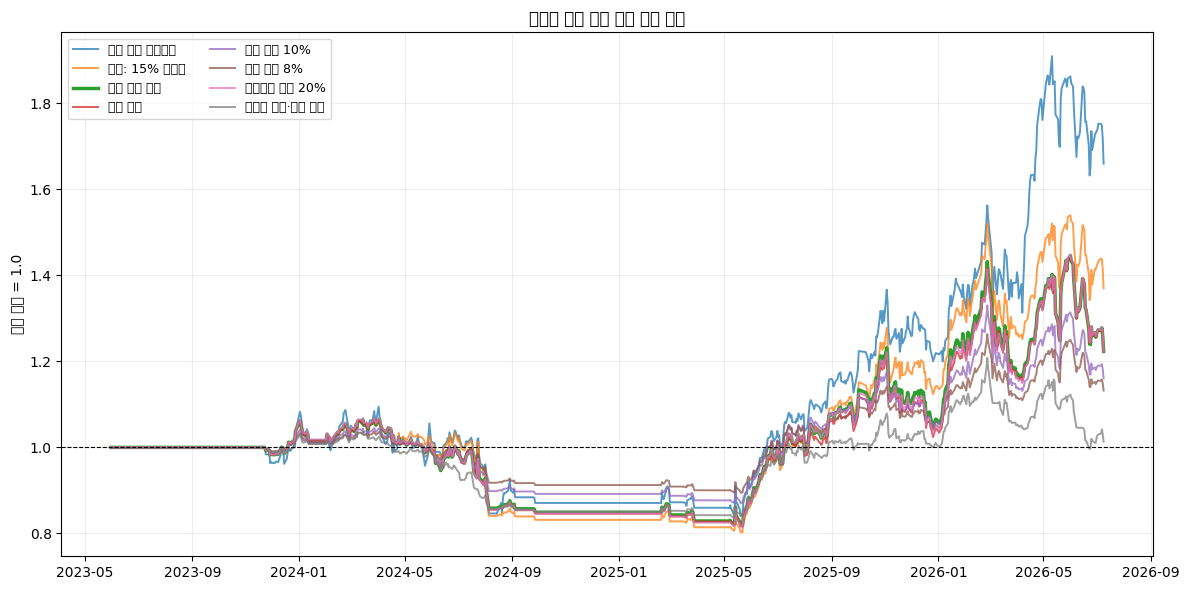

In [4]:
equity = (1 + returns[selected]).cumprod()
fig, ax = plt.subplots(figsize=(12, 6))
for code in selected:
    width = 2.5 if code == 'A_CURRENT' else 1.4
    alpha = 1.0 if code == 'A_CURRENT' else 0.75
    ax.plot(equity.index, equity[code], label=labels[code], linewidth=width, alpha=alpha)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('후보별 비용 차감 누적 자산 배수')
ax.set_ylabel('시작 자산 = 1.0')
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

기존 연구 A0는 가장 높은 누적수익을 보이지만 종목 상한과 가격 손절이 없어 운영 후보가 아니다. 현재 규칙 A는 A0보다 수익이 크게 낮고 비용은 더 높다. 15% 상한만 적용한 진단 후보가 현재 규칙보다 나은 것은 가격 손절·재진입 경로가 수익을 훼손한다는 증거이지만, 그 후보의 MDD와 최악의 날 손실은 오히려 나빠 손절 제거를 정당화하지 않는다.

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1164567718.py:11: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1164567718.py:11: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1164567718.py:11: UserWarning: Glyph 45209 (\N{HANGUL SYLLABLE NAG}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1164567718.py:11: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1164567718.py:11: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1164567718.py:11: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.

C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) m

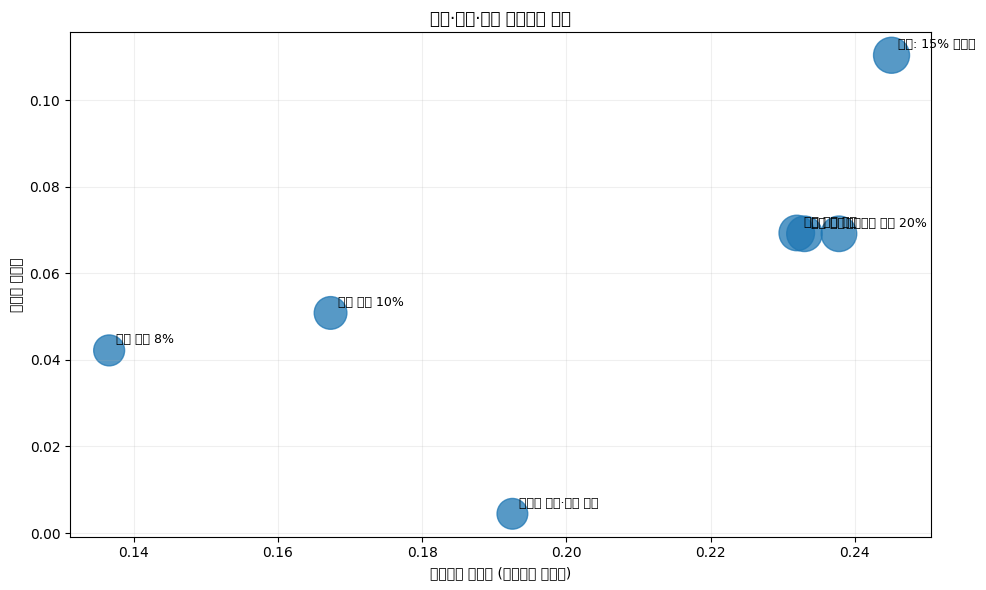

In [5]:
plot_data = summary.loc[[c for c in selected if c != 'A0_LEGACY']]
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 250 + plot_data['average_exposure'] * 900
ax.scatter(plot_data['full_mdd'].abs(), plot_data['full_cagr'], s=sizes, alpha=0.75)
for code, row in plot_data.iterrows():
    ax.annotate(labels[code], (abs(row['full_mdd']), row['full_cagr']), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('최대낙폭 절대값 (낮을수록 방어적)')
ax.set_ylabel('연복리 수익률')
ax.set_title('수익·낙폭·평균 투자비중 비교')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

10%와 8% 종목 상한은 MDD를 각각 -16.73%, -13.66%로 낮췄지만 평균 투자비중도 33.7%, 27.3%로 떨어졌다. 이는 신호가 좋아졌다기보다 현금 비중이 늘어난 효과다. 위험 한도를 우선한다면 8~10% 상한은 유효한 수단이지만 수익률 개선안으로 부를 수는 없다.

In [6]:
stop_reentry_rows = []
for code in ['A_CURRENT', 'X_COOLDOWN5', 'B_EQUAL', 'C_CAP10', 'C_CAP08', 'D_BAND20', 'E_VOL_RISK']:
    frame = events[events['variant'].eq(code)].sort_values(['ticker', 'date'])
    stops = frame[frame['reason'].isin(['HARD_STOP', 'TRAILING_STOP'])]
    gaps = []
    for _, stop in stops.iterrows():
        next_entry = frame[(frame['ticker'].eq(stop['ticker'])) & (frame['date'].gt(stop['date'])) & (frame['reason'].eq('ENTRY'))]
        if not next_entry.empty:
            gaps.append((next_entry.iloc[0]['date'] - stop['date']).days)
    stop_reentry_rows.append({
        'variant': code,
        'stops': len(stops),
        'reentry_within_1d': sum(g <= 1 for g in gaps),
        'reentry_within_5d': sum(g <= 5 for g in gaps),
        'median_reentry_days': float(pd.Series(gaps).median()) if gaps else np.nan,
        'total_events': len(frame),
    })
stop_reentry = pd.DataFrame(stop_reentry_rows).set_index('variant')
stop_reentry

,stops,reentry_within_1d,reentry_within_5d,median_reentry_days,total_events
variant,,,,,
A_CURRENT,123,58,92,1.0,743
X_COOLDOWN5,100,0,0,10.0,536
B_EQUAL,123,58,92,1.0,798
C_CAP10,123,58,92,1.0,514
C_CAP08,123,58,92,1.0,489
D_BAND20,123,58,92,1.0,570
E_VOL_RISK,143,0,0,9.0,426


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1172463125.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1172463125.py:13: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1172463125.py:13: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1172463125.py:13: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1172463125.py:13: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_14572\1172463125.py:13: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  plt

C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\project\Service_Stock_Analysis\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN

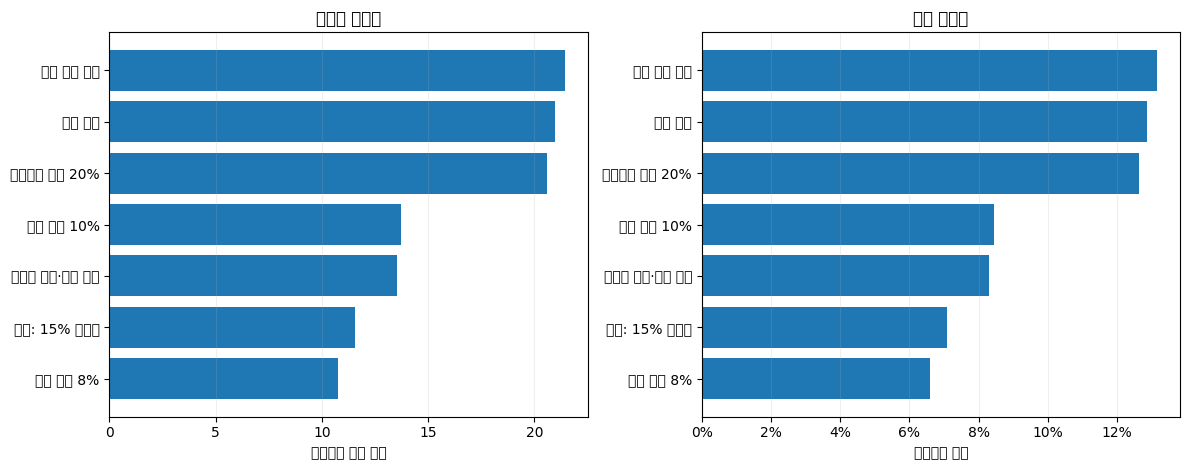

In [7]:
cost_turnover = summary.loc[[c for c in selected if c != 'A0_LEGACY'], ['full_cost', 'annual_turnover']].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
order = cost_turnover.sort_values('annual_turnover').index
axes[0].barh([labels[c] for c in order], cost_turnover.loc[order, 'annual_turnover'])
axes[0].set_title('연환산 회전율')
axes[0].set_xlabel('기초자산 대비 배수')
axes[1].barh([labels[c] for c in order], cost_turnover.loc[order, 'full_cost'])
axes[1].set_title('누적 비용률')
axes[1].set_xlabel('기초자산 대비')
axes[1].xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
for ax in axes:
    ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

현재 근사 규칙은 연환산 회전율 21.4배, 누적 비용률 13.16%다. 최근 PASS/PUBLISHED 구간에서는 연환산 회전율이 45.8배까지 올라갔다. 20% 밴드는 전체 회전율을 21.4배에서 20.6배로만 낮췄다. 손절 123회 중 92회가 5일 안에 재진입했고 중앙값이 1일이므로, 비중 밴드보다 청산 뒤 동일 조건 재진입이 거래량을 지배한다.

In [8]:
yearly = periods[periods['variant'].isin(selected)].pivot(index='variant', columns='period', values='total_return').reindex(selected)
yearly.style.format('{:.2%}').background_gradient(cmap='RdYlGn', axis=None)

period,2023,2024,2025,2026
variant,,,,
A0_LEGACY,3.71%,-16.02%,39.90%,36.16%
X_CAP15_ONLY,3.84%,-19.90%,37.49%,19.77%
A_CURRENT,3.84%,-18.21%,25.36%,14.87%
B_EQUAL,3.84%,-18.53%,23.28%,17.21%
C_CAP10,2.51%,-12.98%,18.78%,9.56%
C_CAP08,1.98%,-10.52%,15.14%,7.76%
D_BAND20,3.85%,-18.49%,24.14%,16.33%
E_VOL_RISK,1.36%,-16.12%,18.36%,0.71%


연도별 성과도 안정적이지 않다. 모든 운영 가능 후보는 2024년에 손실이었고, 2026년 전체 선택 이력과 최근 PASS/PUBLISHED 선택만 사용한 결과의 방향도 다르다. 후보 순위가 구간 선택에 민감하므로 한 구간의 최고 수익률만으로 채택하면 안 된다.

In [9]:
robustness = pd.DataFrame({
    'variant': list(full['robustness']['deflated_sharpe_probability']),
    'deflated_sharpe_probability': list(full['robustness']['deflated_sharpe_probability'].values()),
}).set_index('variant').sort_values('deflated_sharpe_probability', ascending=False)
print('CSCV PBO:', full['robustness']['cscv']['pbo'])
robustness.style.format('{:.1%}')

CSCV PBO: 0.37142857142857144


,deflated_sharpe_probability
variant,
A0_LEGACY,81.2%
X_CAP15_ONLY,70.1%
B_EQUAL,60.5%
A_CURRENT,60.4%
D_BAND20,60.2%
C_CAP10,58.9%
C_CAP08,58.6%
X_COOLDOWN5,58.5%
E_VOL_RISK,37.7%


현재 규칙의 Deflated Sharpe 확률은 60.4%이며, 전체 후보군의 CSCV PBO는 37.1%다. 통상적인 강한 채택 근거로 보기 부족하다. 최근 107거래일은 PBO 계산 자체가 불가능하다. 현재 결과는 후보 제거에는 쓸 수 있지만 최종 채택에는 부족하다.

## Takeaways

1. **지금 PAPER 파라미터를 바꾸지 않는다.** 모든 운영 가능 후보가 최근 구간에서 손실이고 통계적 강건성도 부족하다.
2. **동일 비중과 20% 밴드는 우선순위가 낮다.** 현재 규칙 대비 전체·최근 구간 개선이 사실상 없었다.
3. **8~10% 상한은 위험 예산 선택지로만 남긴다.** MDD를 줄이지만 대부분 낮은 투자비중의 결과이며 수익 개선안이 아니다.
4. **단순히 손절을 강화하거나 5일 쿨다운을 넣지 않는다.** 두 실험 모두 최근 성과를 악화시켰다. 다음 실험은 손절 뒤 기존 진입 조건보다 강한 재진입 확인 조건을 요구하는 히스테리시스 방식이어야 한다.
5. **먼저 리플레이와 운영의 차이를 줄인다.** 최신 가격, 정수 주식, 장중 고점, 부분체결·거절·모호한 주문 결과를 포함한 이벤트 기반 리플레이가 다음 승인 게이트다.
6. **실제 5억 원금 손익 원장을 별도로 복원한다.** 백테스트 결과는 현재 -5.95% 손실의 원장상 원인을 대신 설명하지 못한다.

## Caveats

- 이 결과는 REAL 실행 근거가 아니며 PAPER 설정도 변경하지 않았다.
- A0는 기존 연구 재현용으로 운영 후보가 아니다.
- 고정 비용률은 실제 주문 실패·부분체결·세금 누락을 완전히 설명하지 못한다.
- 전체 결과의 데이터 품질은 LOW, 최근 결과는 표본 길이 때문에 MEDIUM이다.